In [1]:
from natural_pdf import PDF

pdf = PDF("../pdfs/01-practice.pdf")
page = pdf.pages[0]

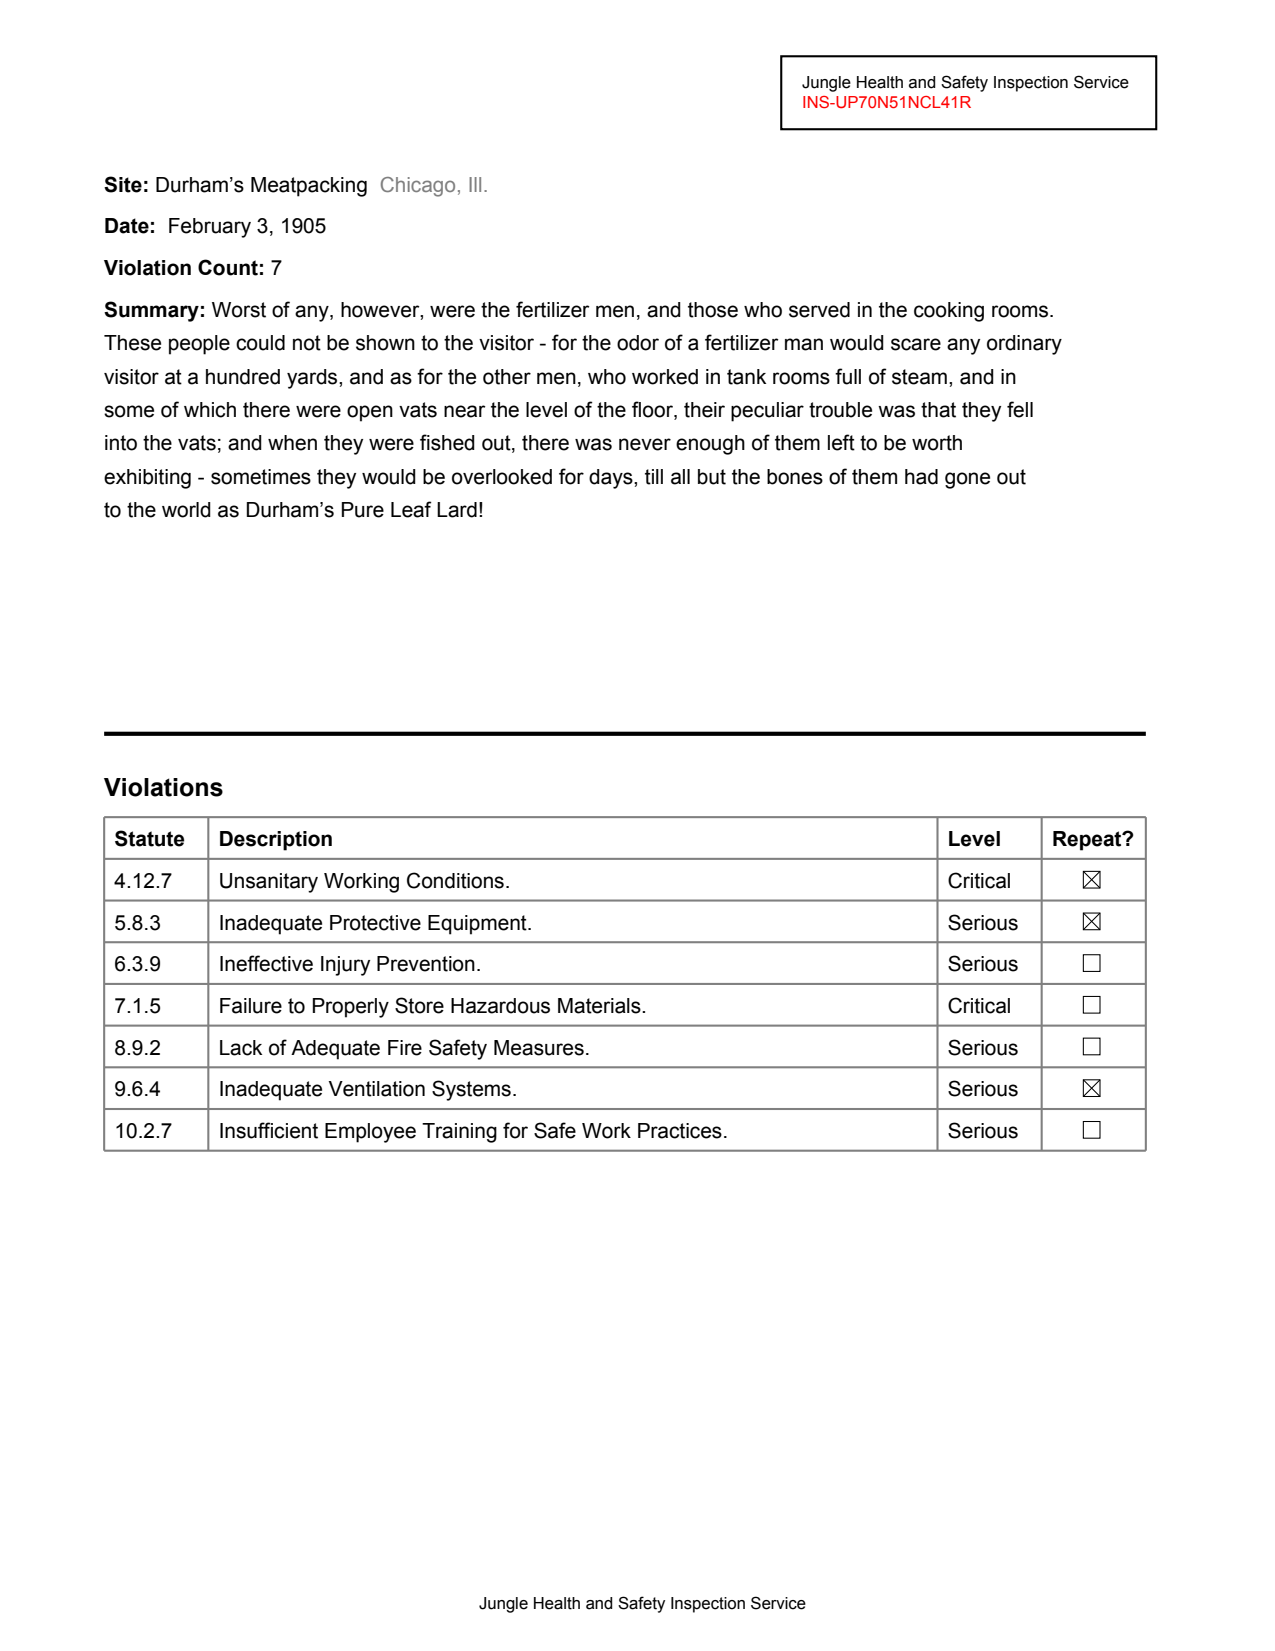

In [2]:
# Explore the page
page.show()

In [4]:
page.find("text[color~=red]").extract_text()

'INS-UP70N51NCL41R'

In [7]:
page.find("text:contains('Site')").right(until='text').expand(right=-1).extract_text()

'Durham’s Meatpacking'

In [8]:
page.find("text:contains('Date')").right().extract_text()

'February 3, 1905'

In [9]:
page.find("text[color~=grey]").extract_text()

'Chicago, Ill.'

In [12]:
(
    page
    .find("text:contains(Summary)")
    .below(until='line', include_source=True)
    .extract_text()
    .replace("Summary:", "")
    .strip()
)

'Worst of any, however, were the fertilizer men, and those who served in the cooking rooms.\nThese people could not be shown to the visitor - for the odor of a fertilizer man would scare any ordinary\nvisitor at a hundred yards, and as for the other men, who worked in tank rooms full of steam, and in\nsome of which there were open vats near the level of the floor, their peculiar trouble was that they fell\ninto the vats; and when they were fished out, there was never enough of them left to be worth\nexhibiting - sometimes they would be overlooked for days, till all but the bones of them had gone out\nto the world as Durham’s Pure Leaf Lard!'

In [26]:
df = page.find("text:contains(Violations)[size=max()]").below().extract_table().to_df()
df

,Statute,Description,Level,Repeat?
0,4.12.7,Unsanitary Working Conditions.,Critical,<NA>
1,5.8.3,Inadequate Protective Equipment.,Serious,<NA>
2,6.3.9,Ineffective Injury Prevention.,Serious,<NA>
3,7.1.5,Failure to Properly Store Hazardous Materials.,Critical,<NA>
4,8.9.2,Lack of Adequate Fire Safety Measures.,Serious,<NA>
5,9.6.4,Inadequate Ventilation Systems.,Serious,<NA>
6,10.2.7,Insufficient Employee Training for Safe Work P...,Serious,<NA>


In [28]:
# Extract separately
df['Repeat?'] = (
    page
    .find("text:contains(Repeat?)")
    .below(width='element')
    .find_all('rect')
    .apply(lambda cell: 'yes' if cell.find('line') else 'no')
)
df

,Statute,Description,Level,Repeat?
0,4.12.7,Unsanitary Working Conditions.,Critical,yes
1,5.8.3,Inadequate Protective Equipment.,Serious,yes
2,6.3.9,Ineffective Injury Prevention.,Serious,no
3,7.1.5,Failure to Properly Store Hazardous Materials.,Critical,no
4,8.9.2,Lack of Adequate Fire Safety Measures.,Serious,no
5,9.6.4,Inadequate Ventilation Systems.,Serious,yes
6,10.2.7,Insufficient Employee Training for Safe Work P...,Serious,no
